In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid")
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [5]:
# Cell 2: Load Processed Data
# We load the data we saved at the end of Phase 1

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

# Separate Features (X) and Target (y)
X_train = train_df.drop('math score', axis=1)
y_train = train_df['math score']

X_test = test_df.drop('math score', axis=1)
y_test = test_df['math score']

# For our Baseline, we will ONLY use the numerical features (Reading and Writing scores)
# This proves why we need a baseline: to see if adding complex categorical features later actually helps!
numerical_features = ['reading score', 'writing score']

X_train_base = X_train[numerical_features]
X_test_base = X_test[numerical_features]

print(f"Baseline Training Data Shape: {X_train_base.shape}")
print(f"Baseline Testing Data Shape: {X_test_base.shape}")

Baseline Training Data Shape: (800, 2)
Baseline Testing Data Shape: (200, 2)


In [6]:
print(train_df)

     reading score  writing score  gender_male  race/ethnicity_group B  \
0         0.030791       0.434053        False                   False   
1         0.930290       0.964701        False                   False   
2         1.345443       1.163694        False                   False   
3        -0.176786      -0.162925         True                   False   
4        -0.384363      -0.759904         True                   False   
..             ...            ...          ...                     ...   
795       2.106557       2.092328        False                   False   
796      -0.453555      -0.494580         True                   False   
797      -0.522747      -1.025228        False                   False   
798      -1.491438      -1.025228         True                   False   
799       1.483827       1.362687        False                   False   

     race/ethnicity_group C  race/ethnicity_group D  race/ethnicity_group E  \
0                     False     

In [12]:
# Cell 3: MLflow Tracking and Model Training

# 1. Setup MLflow Tracking
# Point to the SQLite database we started in the terminal
mlflow.set_tracking_uri("sqlite:///../mlflow1.db")

# Create or set the experiment
mlflow.set_experiment("Student_Performance_Prediction")

# 2. Start MLFlow run
with mlflow.start_run(run_name="Baseline_LinearRegression"):
    # Initialise and train model
    model = LinearRegression()
    model.fit(X_train_base, y_train)

    # predict on the test set
    y_pred = model.predict(X_test_base)

    # Calculate Metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    r2_score = r2_score(y_test, y_pred)

    print("--- Baseline Model Metrics ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2 Score: {r2_score:.4f}")

    # Log everything into MLFlow
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("features", "Numerical Only (reading, writing)")

    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("r2_score", r2_score)

    mlflow.sklearn.log_model(model, "baseline_model")

    print("\n✅ Run logged to MLflow successfully!")


2026/04/07 14:16:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/07 14:16:42 INFO mlflow.store.db.utils: Updating database tables
2026/04/07 14:16:58 INFO mlflow.tracking.fluent: Experiment with name 'Student_Performance_Prediction' does not exist. Creating a new experiment.


--- Baseline Model Metrics ---
RMSE: 8.79
MAE:  7.35
R2 Score: 0.6826


2026/04/07 14:17:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/07 14:17:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



✅ Run logged to MLflow successfully!


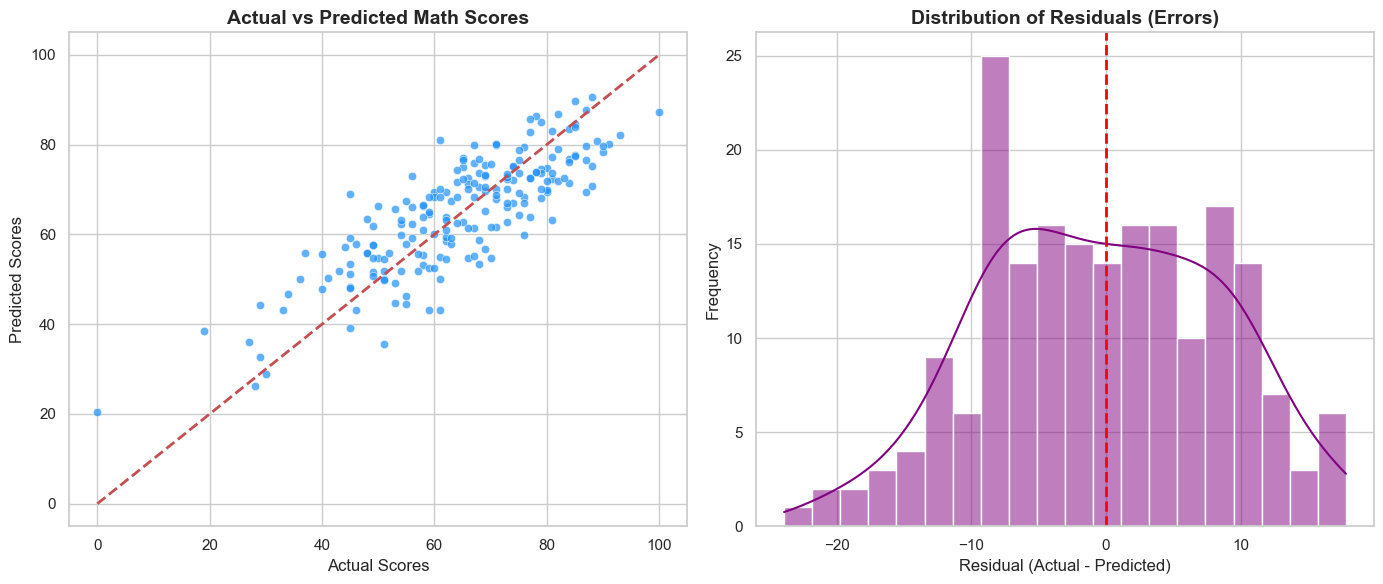

Notice the scatter plot: Is it tightly hugging the red line? If yes, the baseline is already very strong!


In [13]:
# Cell 4: Visualizing Model Performance

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Actual vs Predicted Scatter Plot
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred, alpha=0.7, color='dodgerblue')
# Add perfect prediction line (y=x)
axes[0].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Math Scores', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Scores')
axes[0].set_ylabel('Predicted Scores')

# 2. Residuals Plot (Errors)
residuals = y_test - y_pred
sns.histplot(ax=axes[1], x=residuals, bins=20, kde=True, color='purple')
axes[1].axvline(0, color='red', linestyle='dashed', linewidth=2)
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

# Save the plot and log it to MLflow as an artifact!
plt.savefig("baseline_evaluation.png")
mlflow.log_artifact("baseline_evaluation.png")

plt.show()

print("Notice the scatter plot: Is it tightly hugging the red line? If yes, the baseline is already very strong!")